# Importing the Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Data Collection and Data Prepocessing

In [33]:
#Loading the Dataset to a Pandas DataFrame
sonar_data = pd.read_csv("C:\\Users\\abhis\\Downloads\\Copy of sonar data.csv")
print(sonar_data)

     0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109  \
0    0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
1    0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
2    0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
3    0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
4    0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
202  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   
203  0.0323  0.0101  0.0298  0.0564  0.0760  0.0958  0.0990  0.1018  0.1030   
204  0.0522  0.0437  0.0180  0.0292  0.0351  0.1171  0.1257  0.1178  0.1258   
205  0.0303  0.0353  0.0490  0.0608  0.0167  0.1354  0.1465  0.1123  0.1945   
206  0.0260  0.0363  0.0136  0.0272  0.0214  0.0338  0.0655  0.1400  0.1843   

     0.2111  ...  0.0027  0.0065  0.0159  0.0072  0

In [34]:
sonar_data.head()#First 5 Rows of The DataFrame.

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [35]:
sonar_data.tail()#Last 5 Rows of The DataFrame.

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
202,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
203,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
204,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
205,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M
206,0.0260,0.0363,0.0136,0.0272,0.0214,0.0338,0.0655,0.1400,0.1843,0.2354,...,0.0146,0.0129,0.0047,0.0039,0.0061,0.0040,0.0036,0.0061,0.0115,M


In [36]:
#Calculating the no. of rows and columns.
sonar_data.shape

(207, 61)

In [37]:
sonar_data.describe()#Descriptive stastics of the data.


,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,...,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,0.029208,0.038443,0.043837,0.054053,0.075105,0.104599,0.121591,0.134677,0.177361,0.208245,...,0.016034,0.013472,0.010729,0.010917,0.009300,0.008181,0.007771,0.007947,0.007936,0.006523
std,0.023038,0.033040,0.038521,0.046583,0.055669,0.059247,0.061897,0.085340,0.118311,0.134741,...,0.012027,0.009628,0.007071,0.007310,0.007103,0.005719,0.005756,0.006485,0.006196,0.005038
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013300,0.016400,0.018900,0.024450,0.037700,0.066950,0.080600,0.080350,0.096750,0.111150,...,0.008350,0.007350,0.005050,0.005350,0.004100,0.004400,0.003700,0.003600,0.003650,0.003100
50%,0.022800,0.030800,0.034200,0.044100,0.062000,0.092100,0.105600,0.111900,0.152200,0.181000,...,0.013800,0.011500,0.009600,0.009300,0.007500,0.006800,0.005900,0.005800,0.006300,0.005300
75%,0.035800,0.048100,0.058200,0.065700,0.101050,0.134150,0.153050,0.169800,0.231500,0.269000,...,0.020700,0.016750,0.014900,0.014450,0.012100,0.010350,0.010350,0.010400,0.010350,0.008550
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [38]:
print(sonar_data.info())  # Shows column names and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float64
 22  0.

In [39]:
print(sonar_data.columns)


Index(['0.0200', '0.0371', '0.0428', '0.0207', '0.0954', '0.0986', '0.1539',
       '0.1601', '0.3109', '0.2111', '0.1609', '0.1582', '0.2238', '0.0645',
       '0.0660', '0.2273', '0.3100', '0.2999', '0.5078', '0.4797', '0.5783',
       '0.5071', '0.4328', '0.5550', '0.6711', '0.6415', '0.7104', '0.8080',
       '0.6791', '0.3857', '0.1307', '0.2604', '0.5121', '0.7547', '0.8537',
       '0.8507', '0.6692', '0.6097', '0.4943', '0.2744', '0.0510', '0.2834',
       '0.2825', '0.4256', '0.2641', '0.1386', '0.1051', '0.1343', '0.0383',
       '0.0324', '0.0232', '0.0027', '0.0065', '0.0159', '0.0072', '0.0167',
       '0.0180', '0.0084', '0.0090', '0.0032', 'R'],
      dtype='object')


In [40]:
sonar_data.iloc[:, 60].value_counts()


R
M    111
R     96
Name: count, dtype: int64

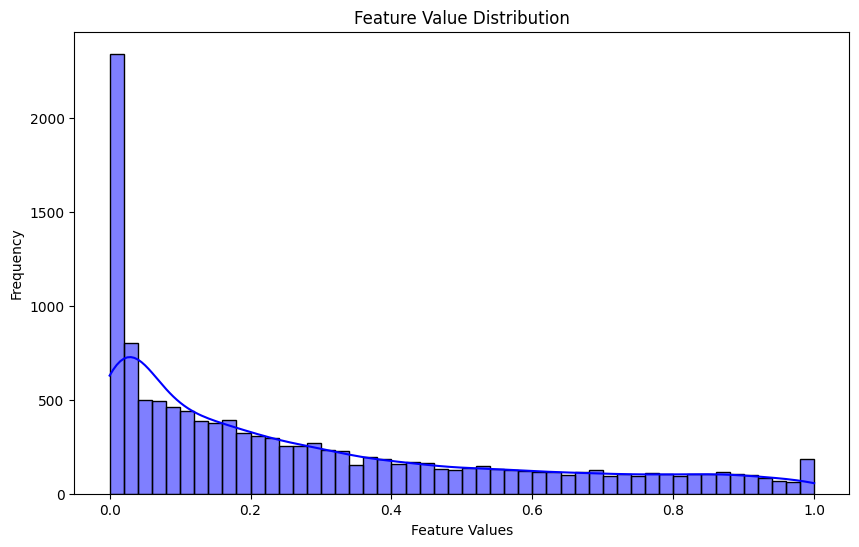

In [41]:
# Visualizing the distribution of features
plt.figure(figsize=(10, 6))
sns.histplot(sonar_data.iloc[:, :-1].values.flatten(), bins=50, kde=True, color='blue')
plt.title("Feature Value Distribution")
plt.xlabel("Feature Values")
plt.ylabel("Frequency")
plt.show()

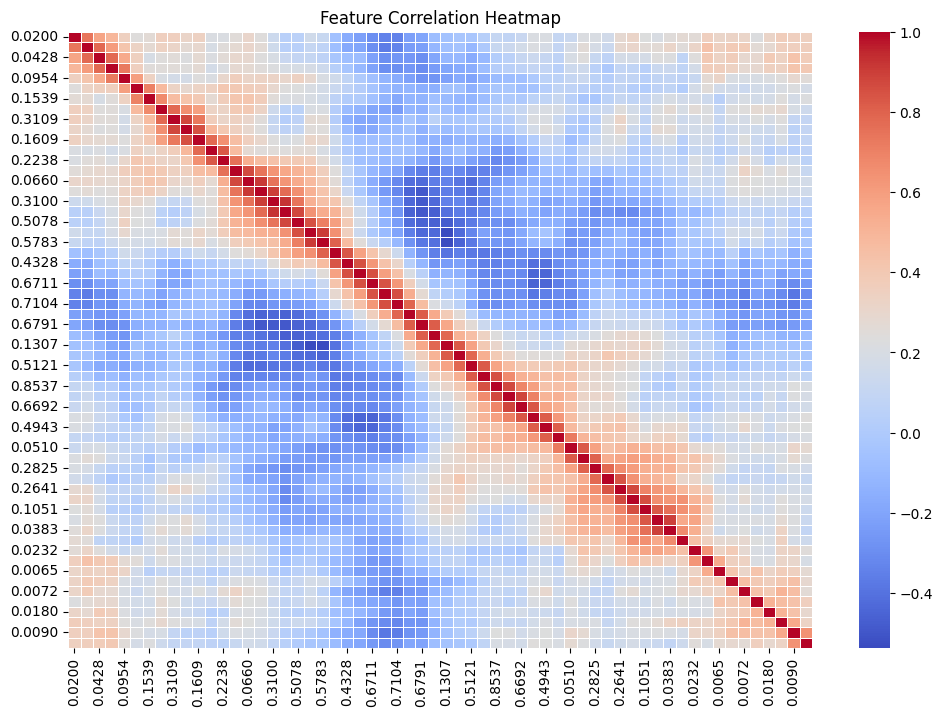

In [42]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(sonar_data.iloc[:, :-1].corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

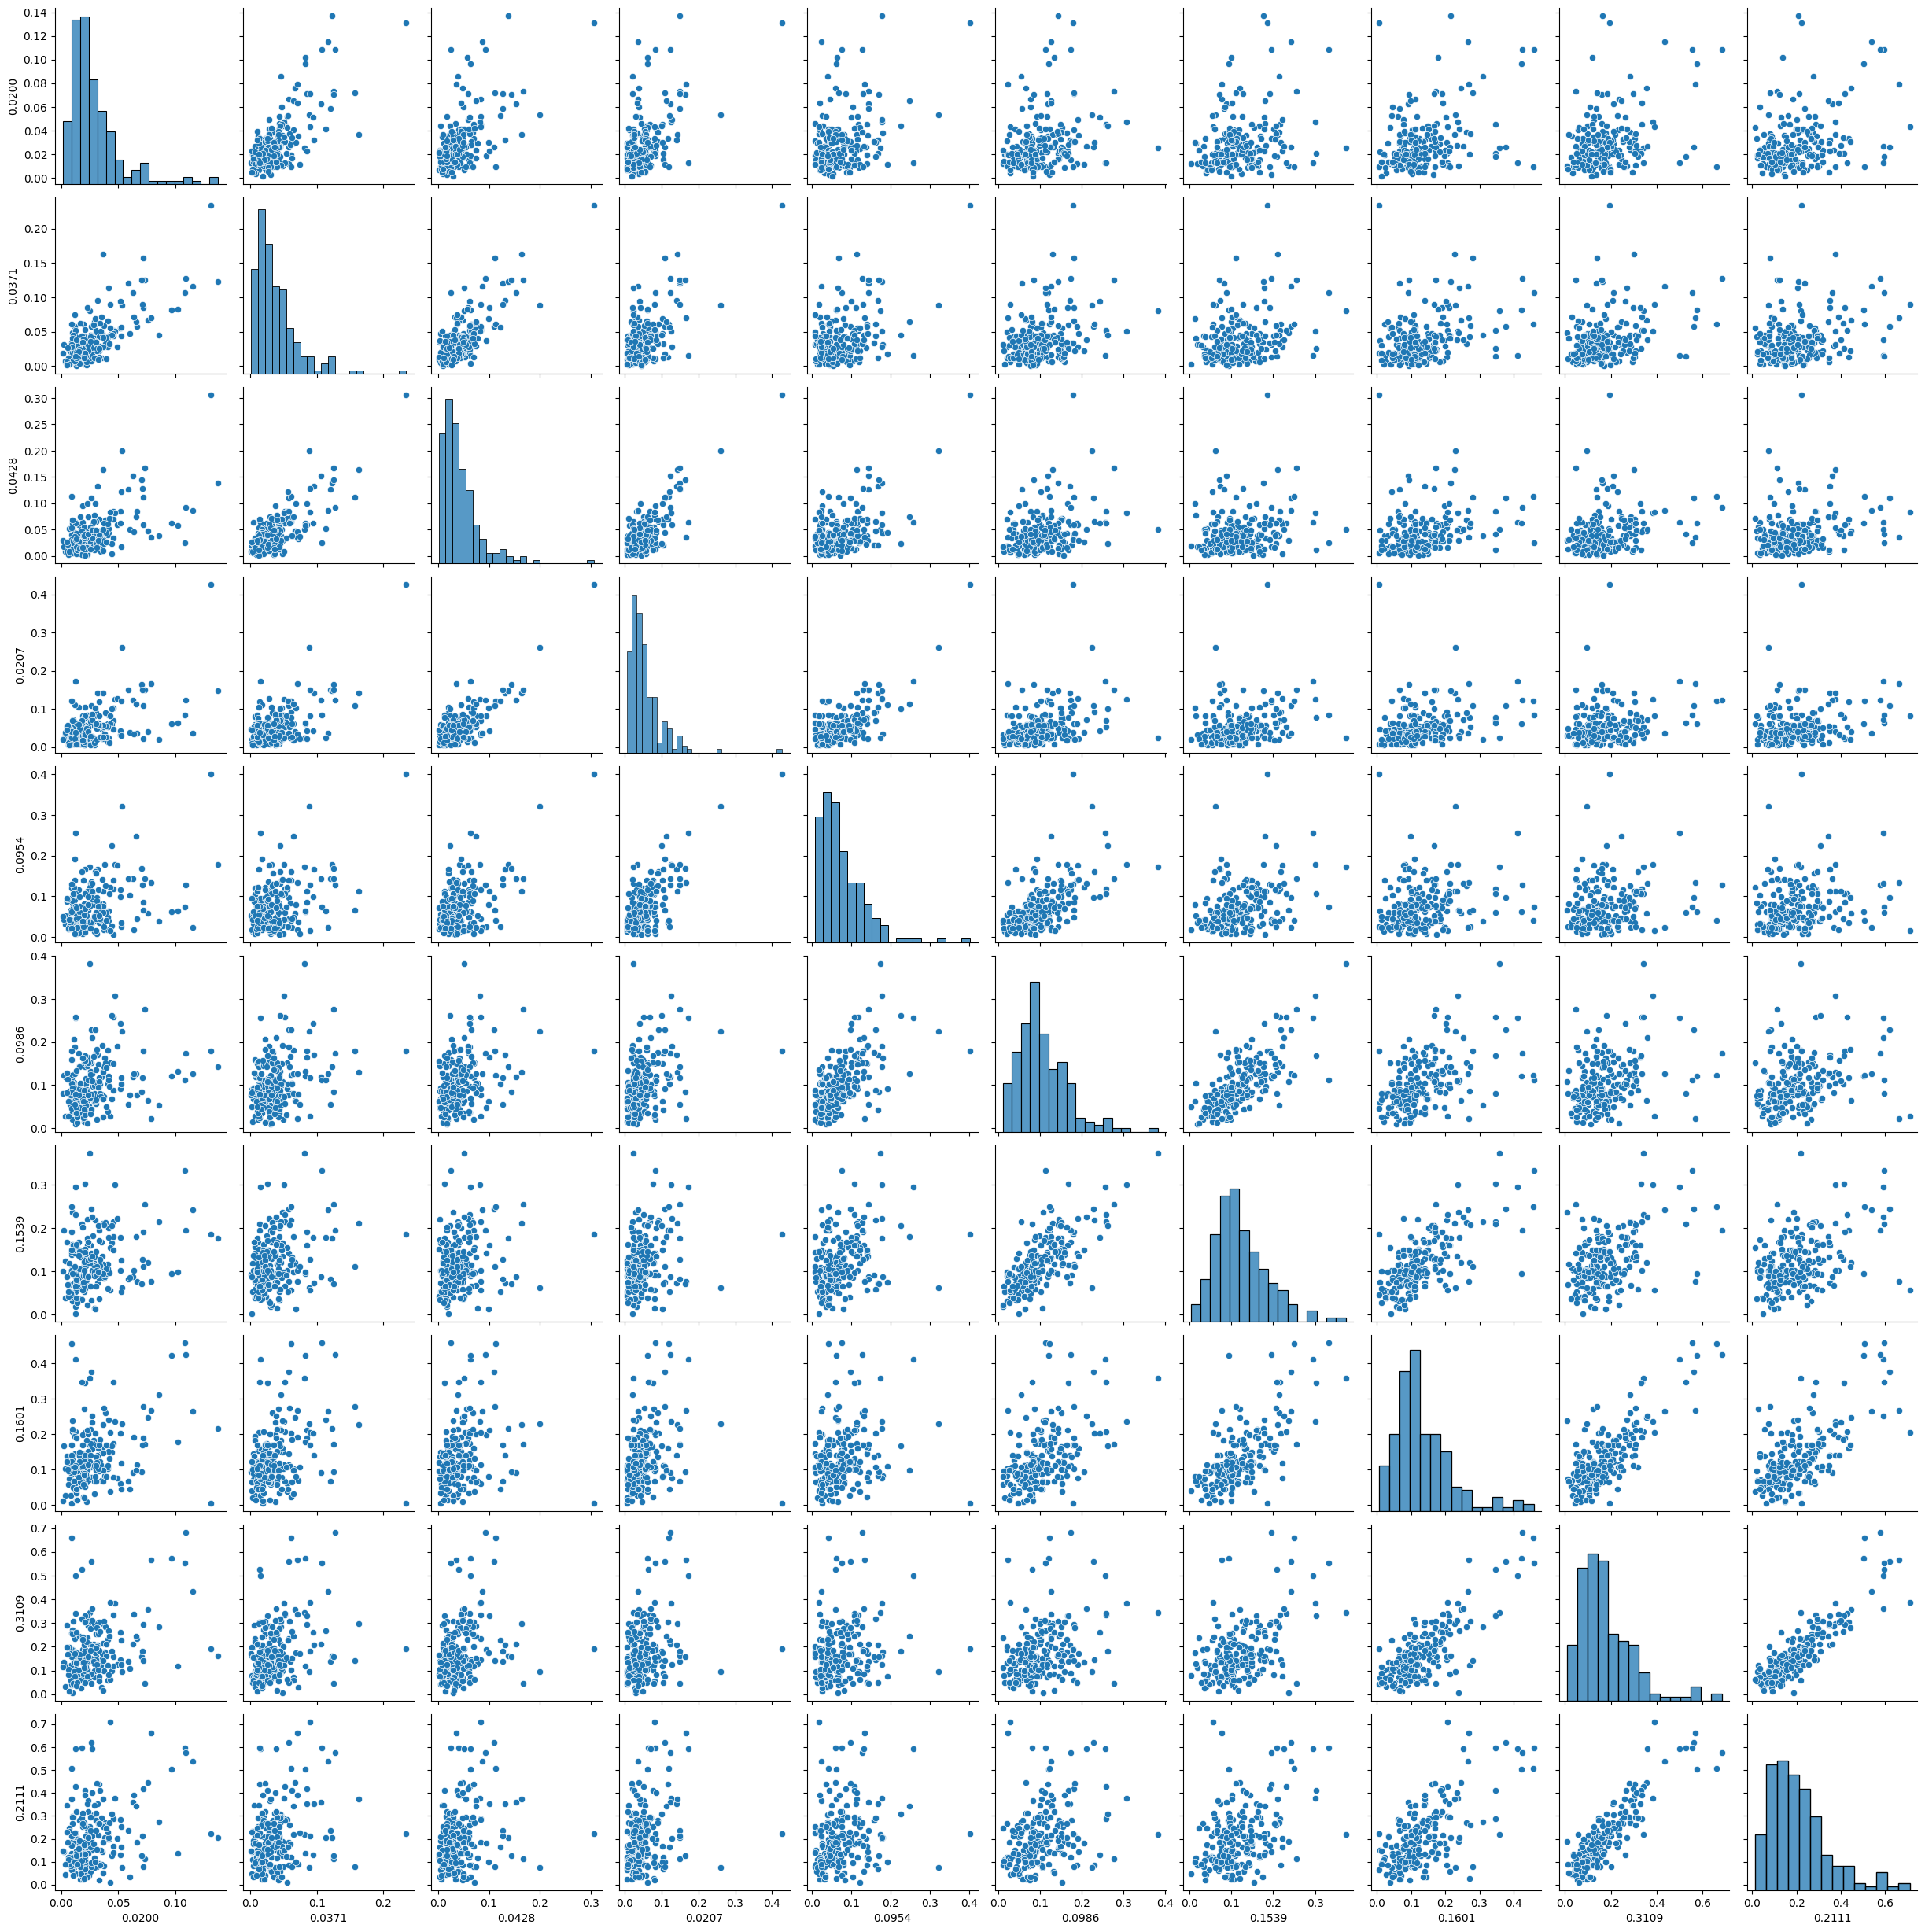

In [43]:
# Pairplot to visualize feature relationships
sns.pairplot(sonar_data.iloc[:, :10])  # Visualizing only first 10 features for clarity
plt.show()

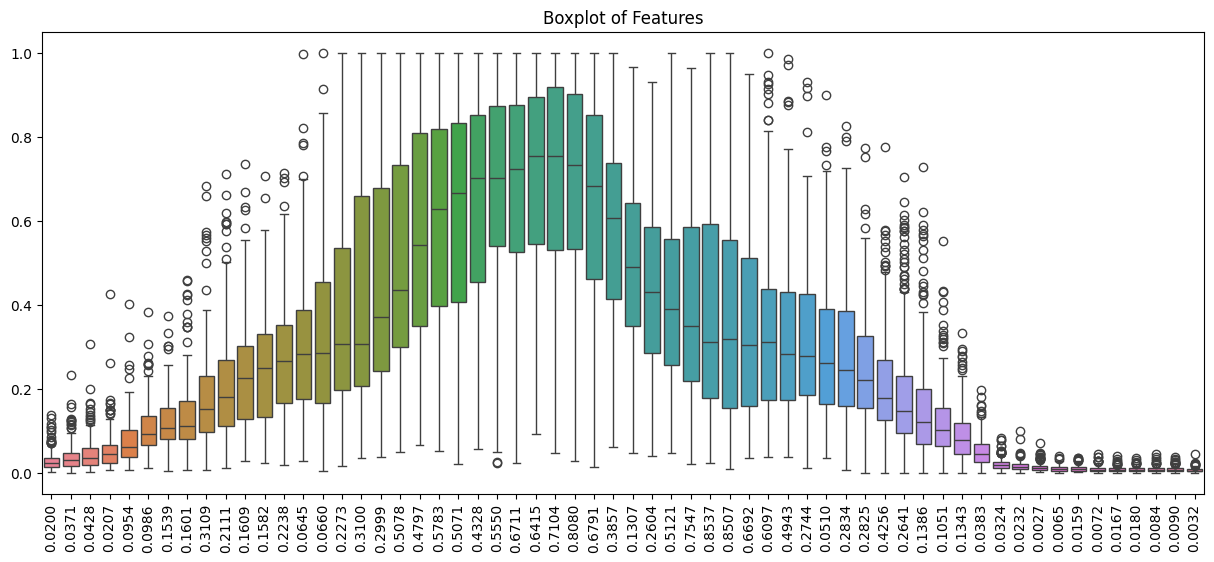

In [44]:
# Boxplot to detect outliers
plt.figure(figsize=(15, 6))
sns.boxplot(data=sonar_data.iloc[:, :-1])
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

In [45]:
# Separate feature (X) and target (y) columns
X = sonar_data.iloc[:, :-1]  # All columns except the last one (features)
y = sonar_data.iloc[:, -1]   # The last column (target: 'R' or 'M')

# Print the separated data
print("Feature Columns (X):")
print(X.head())  # Print first few rows of features

print("\nTarget Column (y):")
print(y.head())  # Print first few values of the target column


Feature Columns (X):
   0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109  \
0  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
1  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
2  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
3  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
4  0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   

   0.2111  ...  0.0232  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  \
0  0.2872  ...  0.0125  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140   
1  0.6194  ...  0.0033  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316   
2  0.1264  ...  0.0241  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050   
3  0.4459  ...  0.0156  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072   
4  0.3039  ...  0.0104  0.0045  0.0014  0.0038  0.0013  0.0089  0.0057   

   0.0084  0.0090  0.0032  
0  0.0049  0.0052  0.0044  
1  0.0164  0.00

In [46]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Training and Evaluationg SVM

In [47]:
# Training the SVM Model.
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Training Prediction
y_train_pred_svm = svm_model.predict(X_train)

# Training Accuracy
accuracy_train_svm = accuracy_score(y_train, y_train_pred_svm)

print("SVM Training Accuracy:", accuracy_train_svm)

# Prediction on Testing Data
y_pred_svm = svm_model.predict(X_test)
accuracy_test_svm = accuracy_score(y_test, y_pred_svm)


print("SVM Testing Accuracy:", accuracy_test_svm)


SVM Training Accuracy: 0.8666666666666667
SVM Testing Accuracy: 0.7619047619047619


## Conclusions from SVM Model

- Training Accuracy: 86.67%

- Testing Accuracy: 76.19%

- Difference: ~10%

- Interpretation:

1) SVM is slightly overfitting but not severely.

2) Training accuracy is higher than testing accuracy, but the gap is not very large.

3) This means the model is learning patterns well.

4) However, some patterns it learned from training data are not fully generalizing to test data.


- Therefore for SVM Model : Mild Overfitting(Acceptable).

## Training and Evaluationg Decision Tree

In [48]:
# Train the Decision Tree Model.
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Training Prediction
y_train_pred_dt = dt_model.predict(X_train)

# Training Accuracy
accuracy_train_dt = accuracy_score(y_train, y_train_pred_dt)

print("Decision Tree Training Accuracy:", accuracy_train_dt)

# Prediction on Testing Data
y_pred_dt = dt_model.predict(X_test)
accuracy_test_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Testing Accuracy:", accuracy_test_dt)



Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.6190476190476191


## Conclusions from Decision Tree Model

- Training Accuracy: 100%

- Testing Accuracy: 61.90%

- Difference: ~38%

- Interpretation:

1) This is a clear case of Overfitting.
    
2) The model perfectly learned the training data.
    
3) But it performs very poorly on testing data
    
4) This means it memorized the training dataset instead of learning general patterns.
    
- Therefore for Decision Tree Model:  High Overfitting


## Training and Evaluationg Logistic Regression

In [49]:
# Train the Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Training Prediction
y_train_pred_lr = lr_model.predict(X_train)

# Training Accuracy
accuracy_train_lr = accuracy_score(y_train, y_train_pred_lr)

print("Logistic Regression Training Accuracy:", accuracy_train_lr)

# Prediction on Testing Data
y_pred_lr = lr_model.predict(X_test)
accuracy_test_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Testing Accuracy:", accuracy_test_lr)




Logistic Regression Training Accuracy: 0.8484848484848485
Logistic Regression Testing Accuracy: 0.7619047619047619


## Conclusions from Logistic Regression Model

- Training Accuracy: 84.84%

- Testing Accuracy: 76.19%

- Difference: ~8%

- Interpretation:

1) Training and testing accuracy are close.
    
2) This means the model generalizes well.
    
3) It is not memorizing data.

4) However, both accuracies are moderate.
    
5) This suggests slight underfitting because Logistic Regression assumes linear relationship, while sonar data is complex.

- Therefore for the Logistic Regression Model :  Underfitting(But Stable Model)

## Training and Evaluating Random Forest

In [56]:
# Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Training Prediction
y_train_pred_rf = rf_model.predict(X_train)

# Training Accuracy
accuracy_train_rf = accuracy_score(y_train, y_train_pred_rf)

print("Random Forest Training Accuracy:", accuracy_train_rf)

# Prediction on Testing Data
y_pred_rf = rf_model.predict(X_test)
accuracy_test_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Testing Accuracy:", accuracy_test_rf)




Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.7857142857142857


## Conclusions from Random Forest Model

- Training Accuracy: 100%

- Testing Accuracy: 78.57%

- Difference: ~21%

- Interpretation:

1) Training accuracy is perfect.
    
2) Testing accuracy is also the highest among all models.
    
3) There is some overfitting, but much less than Decision Tree.
    
4) Random Forest reduces overfitting by averaging multiple trees.
    
5) That is why testing accuracy is still strong.

- Therefore for the Logistic Regression Model : Moderate Overfitting but Best Performance

## Visulisation of Accuracies of Different ML Models

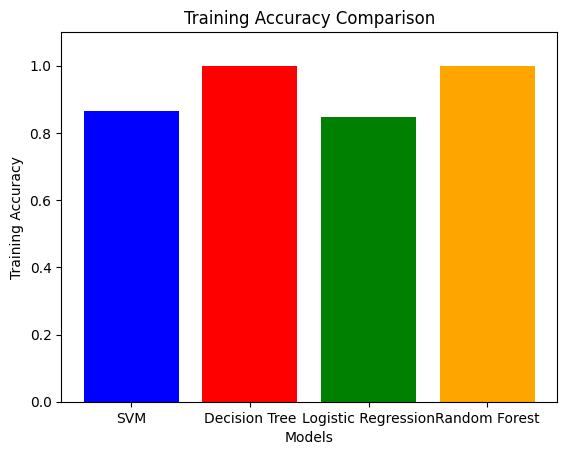

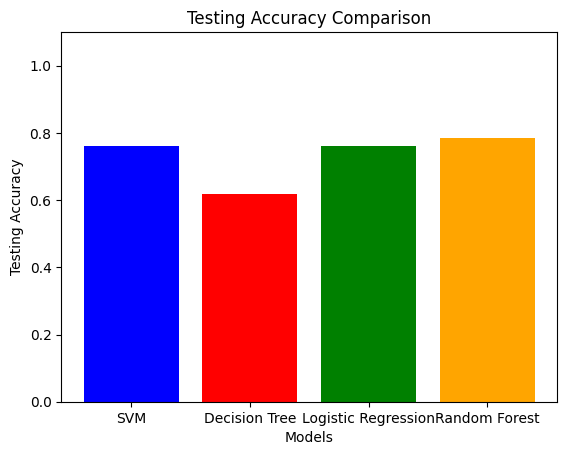

In [61]:
# Model names
models = ['SVM', 'Decision Tree', 'Logistic Regression', 'Random Forest']

# Training and Testing Accuracies
training_accuracies = [0.8667, 1.0, 0.8485, 1.0]
testing_accuracies = [0.7619, 0.6190, 0.7619, 0.7857]

# Colors for bars
colors = ['blue', 'red', 'green', 'orange']


# Training Accuracy Bar Graph

plt.figure()
plt.bar(models, training_accuracies, color=colors)

plt.xlabel("Models")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.ylim(0, 1.1)

plt.show()



# Testing Accuracy Bar Graph

plt.figure()
plt.bar(models, testing_accuracies, color=colors)

plt.xlabel("Models")
plt.ylabel("Testing Accuracy")
plt.title("Testing Accuracy Comparison")
plt.ylim(0, 1.1)

plt.show()

## Final Conclusions of the Project

- Most Overfitting Model: Decision Tree(because training accuracy is 100% but testing is very low).

- Best Balanced Model: SVM(because small gap between training and testing accuracy).

- Best Overall Model: Random Forest(because highest testing accuracy (78.57%) with good generalization).

- Most Stable but Slightly Underfitting: Logistic Regression (because close training and testing accuracy but moderate performance).